In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import h5py
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maneesh99/signs-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.88M/8.88M [00:00<00:00, 11.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/maneesh99/signs-detection-dataset/versions/2


In [ ]:
train_path = os.path.join(path, "Signs_Data_Training.h5")
test_path = os.path.join(path, "Signs_Data_Testing.h5")

In [ ]:
with h5py.File(train_path, "r") as f:
    print(list(f.keys()))

['list_classes', 'train_set_x', 'train_set_y']


In [ ]:
with h5py.File(train_path, "r") as f:
    X_train = np.array(f["train_set_x"])
    y_train = np.array(f["train_set_y"])
    list_classes = np.array(f["list_classes"])
    print(f"List of classes: {list_classes}")
    print(f"Number of classes: {len(list_classes)}")


List of classes: [0 1 2 3 4 5]
Number of classes: 6


In [ ]:
X_train.shape

(1080, 64, 64, 3)

In [ ]:
y_train.shape

(1080,)

In [ ]:
with h5py.File(test_path, "r") as f:
    X_test = np.array(f["test_set_x"])
    y_test = np.array(f["test_set_y"])

In [ ]:
X_test.shape #image

(120, 64, 64, 3)

In [ ]:
y_test.shape #value of sign like 1,2,3,4

(120,)

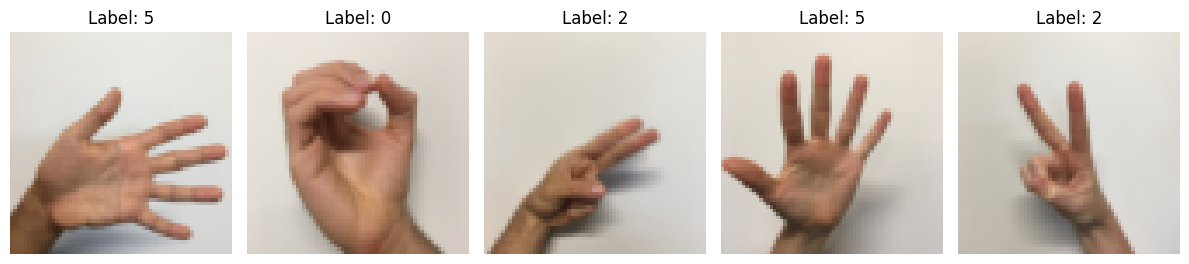

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Model Building

In [ ]:
data_aug=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

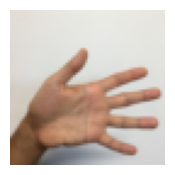

In [ ]:
plt.figure(figsize=(2,3))
plt.imshow(X_train[0])
plt.axis("off")
plt.show()

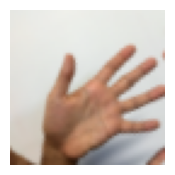

In [ ]:
plt.figure(figsize=(2,3))
plt.imshow(data_aug(X_train)[0].numpy().astype("uint8"))
plt.axis("off")
plt.show()

In [ ]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [ ]:
X_test_scaled[:5]

array([[[[0.90588235, 0.87843137, 0.84705882],
         [0.90980392, 0.87843137, 0.84705882],
         [0.90980392, 0.88235294, 0.85098039],
         ...,
         [0.88627451, 0.85490196, 0.82352941],
         [0.88627451, 0.85098039, 0.81960784],
         [0.88235294, 0.84705882, 0.81568627]],

        [[0.90588235, 0.87843137, 0.84313725],
         [0.90980392, 0.87843137, 0.84313725],
         [0.90588235, 0.88235294, 0.84705882],
         ...,
         [0.88627451, 0.85490196, 0.82352941],
         [0.88235294, 0.85098039, 0.81960784],
         [0.87843137, 0.84705882, 0.81568627]],

        [[0.90588235, 0.8745098 , 0.84313725],
         [0.90588235, 0.87843137, 0.84313725],
         [0.90588235, 0.87843137, 0.84705882],
         ...,
         [0.88235294, 0.85490196, 0.81960784],
         [0.88235294, 0.85490196, 0.81960784],
         [0.87843137, 0.85098039, 0.81568627]],

        ...,

        [[0.78823529, 0.75686275, 0.7254902 ],
         [0.78823529, 0.75686275, 0.7254902 ]

In [ ]:
from sys import meta_path
cnn=tf.keras.Sequential([
    data_aug,
    layers.Conv2D(16,3, padding='same',activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,3, padding='same',activation='relu'),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(6,activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
            )
cnn.fit(X_train_scaled , y_train , epochs=500)

Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1694 - loss: 1.9197
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2352 - loss: 1.7433
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3944 - loss: 1.4976
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4898 - loss: 1.3107
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5435 - loss: 1.1630
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6278 - loss: 0.9816
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6704 - loss: 0.8727
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7361 - loss: 0.7356
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7454 - loss: 0.6967
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7648 - loss: 0.6467
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7741 - loss: 0.6238
Epoch 12/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accura